Shape de X: (6607, 28)

Distribució de la variable objectiu:
dropout
0    5288
1    1319
Name: count, dtype: int64

Distribució relativa de la variable objectiu:
dropout
0    0.800363
1    0.199637
Name: proportion, dtype: float64

XGBoost afegit correctament.

Model: Logistic Regression
Accuracy : 0.9758
Precision: 0.8919
Recall   : 1.0
F1-score : 0.9429
ROC-AUC  : 0.9995

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1058
           1       0.89      1.00      0.94       264

    accuracy                           0.98      1322
   macro avg       0.95      0.98      0.96      1322
weighted avg       0.98      0.98      0.98      1322



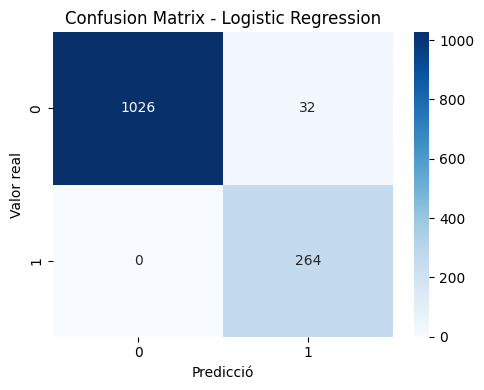


Model: MLP
Accuracy : 0.9796
Precision: 0.9506
Recall   : 0.947
F1-score : 0.9488
ROC-AUC  : 0.9976

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1058
           1       0.95      0.95      0.95       264

    accuracy                           0.98      1322
   macro avg       0.97      0.97      0.97      1322
weighted avg       0.98      0.98      0.98      1322



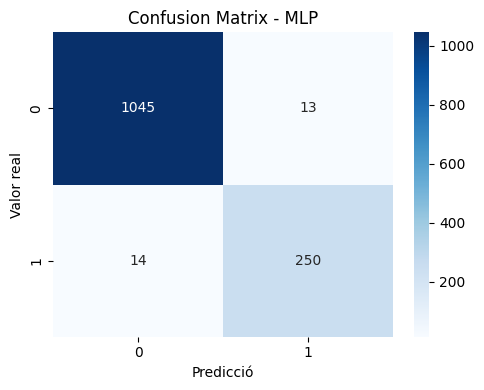


Model: XGBoost
Accuracy : 0.9803
Precision: 0.9474
Recall   : 0.9545
F1-score : 0.9509
ROC-AUC  : 0.998

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1058
           1       0.95      0.95      0.95       264

    accuracy                           0.98      1322
   macro avg       0.97      0.97      0.97      1322
weighted avg       0.98      0.98      0.98      1322



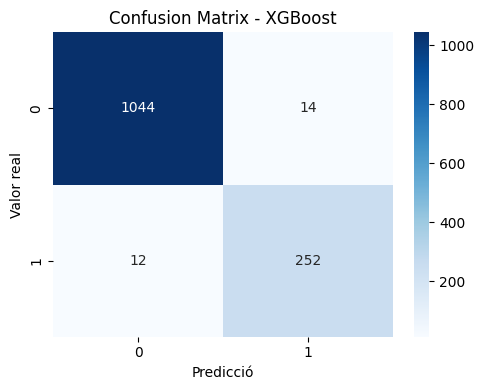


RESULTATS FINALS ORDENATS PER F1-SCORE
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
2              XGBoost  0.980333   0.947368  0.954545  0.950943  0.997963
1                  MLP  0.979576   0.950570  0.946970  0.948767  0.997598
0  Logistic Regression  0.975794   0.891892  1.000000  0.942857  0.999520

TOP VARIABLES - LOGISTIC REGRESSION
                       Variable  Coefficient  AbsCoefficient
14         Motivation_Level_Low    14.189156       14.189156
15      Motivation_Level_Medium     5.424406        5.424406
9                    Exam_Score    -0.828980        0.828980
0                 Hours_Studied    -0.754513        0.754513
8         Learning_Disabilities    -0.377374        0.377374
26      Distance_from_Home_Near     0.375364        0.375364
17         Family_Income_Medium    -0.342154        0.342154
1                    Attendance    -0.324972        0.324972
12      Access_to_Resources_Low    -0.291159        0.291159
18          Teach

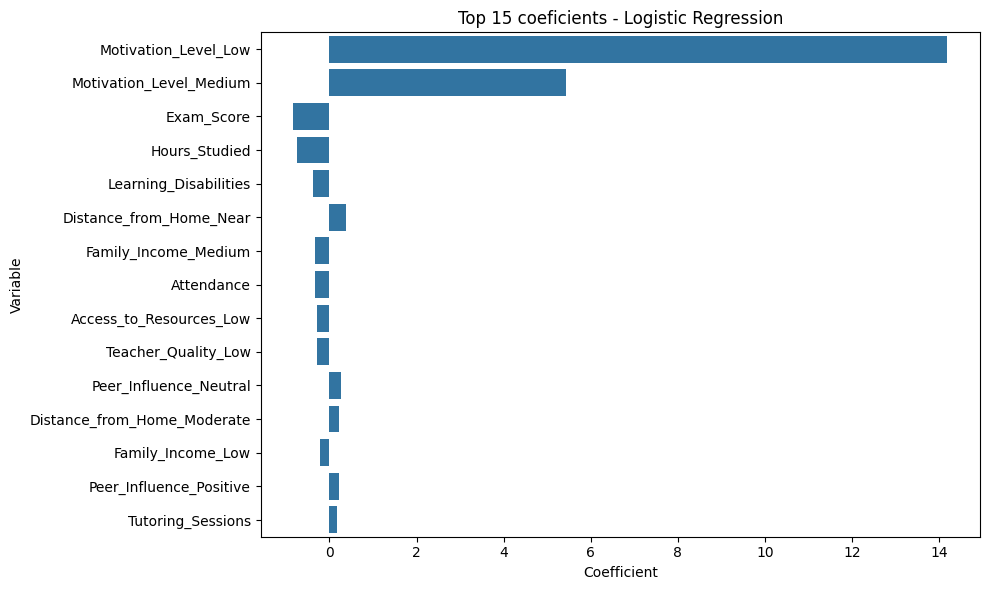


TOP VARIABLES - XGBOOST
                      Variable  Importance
9                   Exam_Score    0.301654
14        Motivation_Level_Low    0.136235
15     Motivation_Level_Medium    0.114722
0                Hours_Studied    0.080313
1                   Attendance    0.069637
4              Previous_Scores    0.050861
10    Parental_Involvement_Low    0.027094
6            Tutoring_Sessions    0.021640
12     Access_to_Resources_Low    0.015776
8        Learning_Disabilities    0.013730
26     Distance_from_Home_Near    0.013073
27                 Gender_Male    0.011971
18         Teacher_Quality_Low    0.011207
7            Physical_Activity    0.010595
20          School_Type_Public    0.010589
2   Extracurricular_Activities    0.010392
22     Peer_Influence_Positive    0.010136
13  Access_to_Resources_Medium    0.009799
5              Internet_Access    0.009404
17        Family_Income_Medium    0.008984


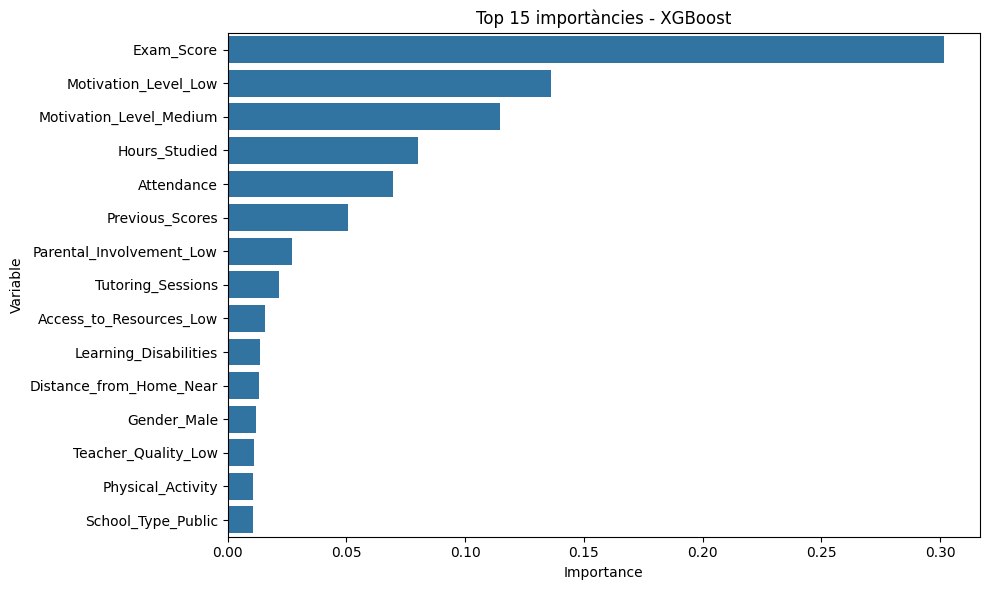

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# =========================================================
# 1. Carregar dataset
# =========================================================
path = r"C:\Users\alber\OneDrive - Universitat Politècnica de Catalunya\UPC\6è Quatri\PAID\student_final.csv"
df = pd.read_csv(path)

# =========================================================
# 2. Definir variable objectiu
# =========================================================
target_col = "dropout"

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# Si la variable objectiu és text, la convertim a 0/1
if y.dtype == "object":
    y = y.map({
        "Yes": 1, "No": 0,
        "Dropout": 1, "No Dropout": 0,
        "True": 1, "False": 0
    })

y = y.astype(int)

# =========================================================
# 3. Convertir variables categòriques a numèriques
# =========================================================
X = pd.get_dummies(X, drop_first=True)

print("Shape de X:", X.shape)
print("\nDistribució de la variable objectiu:")
print(y.value_counts())
print("\nDistribució relativa de la variable objectiu:")
print(y.value_counts(normalize=True))

# Guardem noms de variables per a interpretació posterior
feature_names = X.columns.tolist()

# =========================================================
# 4. Train / test split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# 5. Definir models
# =========================================================
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),


    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        max_iter=500,
        random_state=42
    )
}

# XGBoost opcional
xgb_available = False
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    xgb_available = True
    print("\nXGBoost afegit correctament.")
except ImportError:
    print("\nXGBoost no està instal·lat. Es farà servir Gradient Boosting.")

# =========================================================
# 6. Entrenar i avaluar models
# =========================================================
results = []
trained_models = {}

for model_name, model in models.items():
    print("\n" + "=" * 70)
    print(f"Model: {model_name}")

    model.fit(X_train, y_train)
    trained_models[model_name] = model

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": auc
    })

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    if not np.isnan(auc):
        print("ROC-AUC  :", round(auc, 4))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicció")
    plt.ylabel("Valor real")
    plt.tight_layout()
    plt.show()

# =========================================================
# 7. Comparativa final
# =========================================================
results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)

print("\n" + "=" * 70)
print("RESULTATS FINALS ORDENATS PER F1-SCORE")
print(results_df)

results_df.to_csv("resultats_models_classificacio.csv", index=False, encoding="utf-8-sig")

# =========================================================
# 8. Importància de variables - Logistic Regression
# =========================================================
if "Logistic Regression" in trained_models:
    log_model = trained_models["Logistic Regression"]

    coef_df = pd.DataFrame({
        "Variable": feature_names,
        "Coefficient": log_model.coef_[0]
    })

    coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values(by="AbsCoefficient", ascending=False)

    print("\n" + "=" * 70)
    print("TOP VARIABLES - LOGISTIC REGRESSION")
    print(coef_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=coef_df.head(15),
        x="Coefficient",
        y="Variable"
    )
    plt.title("Top 15 coeficients - Logistic Regression")
    plt.tight_layout()
    plt.show()

# =========================================================
# 9. Importància de variables - Random Forest
# =========================================================
if "Random Forest" in trained_models:
    rf_model = trained_models["Random Forest"]

    rf_imp_df = pd.DataFrame({
        "Variable": feature_names,
        "Importance": rf_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print("\n" + "=" * 70)
    print("TOP VARIABLES - RANDOM FOREST")
    print(rf_imp_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=rf_imp_df.head(15),
        x="Importance",
        y="Variable"
    )
    plt.title("Top 15 importàncies - Random Forest")
    plt.tight_layout()
    plt.show()

# =========================================================
# 10. Importància de variables - XGBoost
# =========================================================
if xgb_available and "XGBoost" in trained_models:
    xgb_model = trained_models["XGBoost"]

    xgb_imp_df = pd.DataFrame({
        "Variable": feature_names,
        "Importance": xgb_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print("\n" + "=" * 70)
    print("TOP VARIABLES - XGBOOST")
    print(xgb_imp_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=xgb_imp_df.head(15),
        x="Importance",
        y="Variable"
    )
    plt.title("Top 15 importàncies - XGBoost")
    plt.tight_layout()
    plt.show()

Logistic Regression: coeficients


Variables més importants segons Logistic Regression:
                       Variable  Coefficient  AbsCoefficient
14         Motivation_Level_Low    14.189156       14.189156
15      Motivation_Level_Medium     5.424406        5.424406
9                    Exam_Score    -0.828980        0.828980
0                 Hours_Studied    -0.754513        0.754513
8         Learning_Disabilities    -0.377374        0.377374
26      Distance_from_Home_Near     0.375364        0.375364
17         Family_Income_Medium    -0.342154        0.342154
1                    Attendance    -0.324972        0.324972
12      Access_to_Resources_Low    -0.291159        0.291159
18          Teacher_Quality_Low    -0.290987        0.290987
21       Peer_Influence_Neutral     0.276631        0.276631
25  Distance_from_Home_Moderate     0.224273        0.224273
16            Family_Income_Low    -0.222428        0.222428
22      Peer_Influence_Positive     0.215521        0.215521
6             Tutoring_Sessions

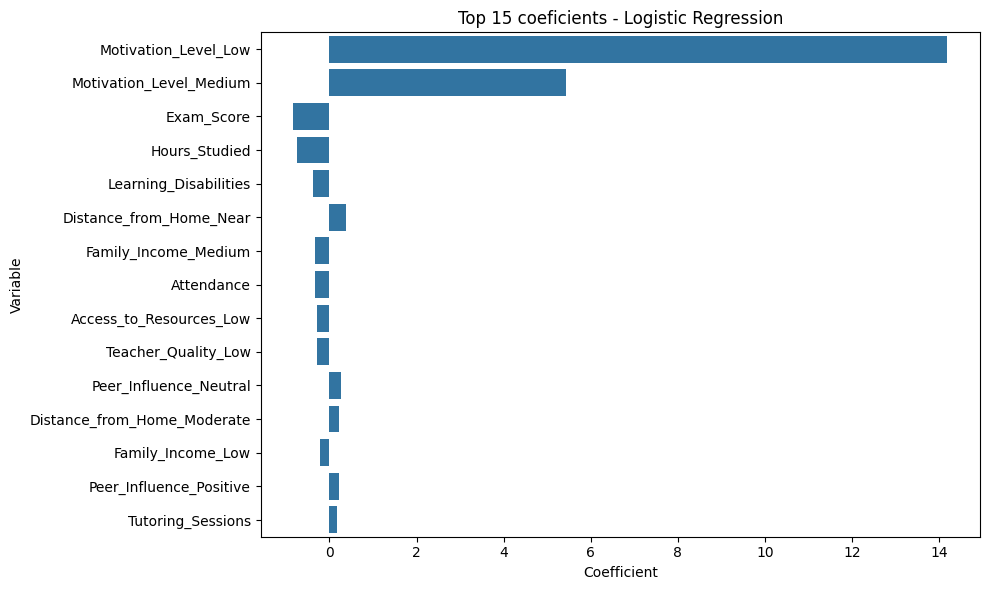

In [3]:
if "Logistic Regression" in trained_models:
    model = trained_models["Logistic Regression"]

    coef_df = pd.DataFrame({
        "Variable": X.columns,
        "Coefficient": model.coef_[0],
        "AbsCoefficient": np.abs(model.coef_[0])
    }).sort_values(by="AbsCoefficient", ascending=False)

    print("\nVariables més importants segons Logistic Regression:")
    print(coef_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df.head(15), x="Coefficient", y="Variable")
    plt.title("Top 15 coeficients - Logistic Regression")
    plt.tight_layout()
    plt.show()

XGBoost: importància de variables


Variables més importants segons XGBoost:
                      Variable  Importance
9                   Exam_Score    0.301654
14        Motivation_Level_Low    0.136235
15     Motivation_Level_Medium    0.114722
0                Hours_Studied    0.080313
1                   Attendance    0.069637
4              Previous_Scores    0.050861
10    Parental_Involvement_Low    0.027094
6            Tutoring_Sessions    0.021640
12     Access_to_Resources_Low    0.015776
8        Learning_Disabilities    0.013730
26     Distance_from_Home_Near    0.013073
27                 Gender_Male    0.011971
18         Teacher_Quality_Low    0.011207
7            Physical_Activity    0.010595
20          School_Type_Public    0.010589
2   Extracurricular_Activities    0.010392
22     Peer_Influence_Positive    0.010136
13  Access_to_Resources_Medium    0.009799
5              Internet_Access    0.009404
17        Family_Income_Medium    0.008984


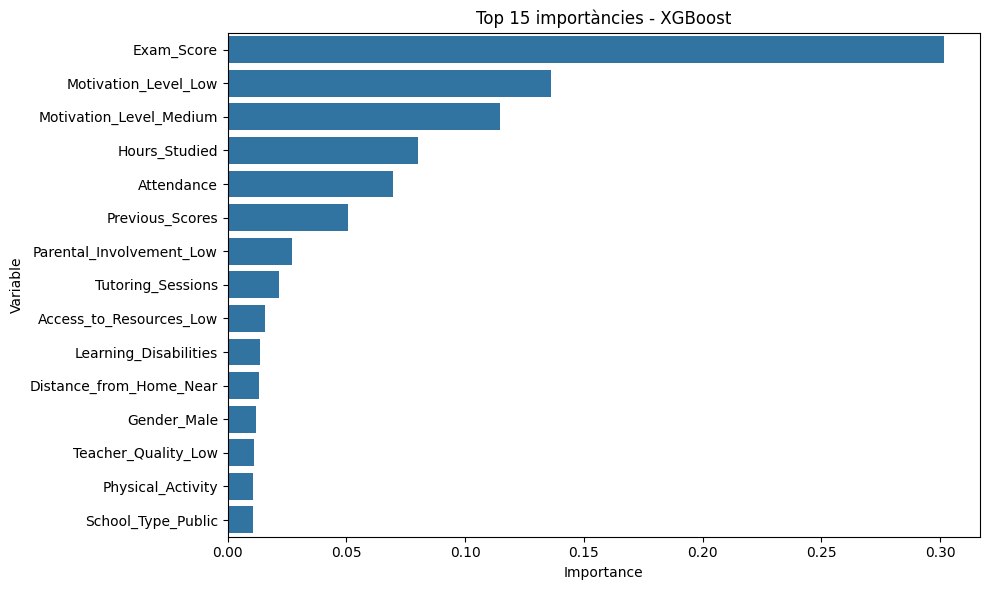

In [7]:
if "XGBoost" in trained_models:
    model = trained_models["XGBoost"]

    xgb_imp_df = pd.DataFrame({
        "Variable": X.columns,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print("\nVariables més importants segons XGBoost:")
    print(xgb_imp_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=xgb_imp_df.head(15), x="Importance", y="Variable")
    plt.title("Top 15 importàncies - XGBoost")
    plt.tight_layout()
    plt.show()